

1. Import Libraries & Upload Data



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

# Load Excel file
xlsx_files = [f for f in uploaded.keys() if f.lower().endswith(".xlsx")]
file_path = xlsx_files[0]

df = pd.read_excel(file_path)

print("Shape:", df.shape)
df.head()

Saving 2024-2026-canadahelp.xlsx to 2024-2026-canadahelp.xlsx
Shape: (278, 15)


,PAYMENT METHOD,DONOR FIRST NAME,DONOR LAST NAME,DONOR COMPANY NAME,DONOR ADDRESS 1,DONOR CITY,DONOR POSTAL/ZIP CODE,DONOR EMAIL ADDRESS,AMOUNT,DONATION DATE,DONATION TIME,FEE,TOTAL DISBURSED,MESSAGE TO CHARITY,DONATION SOURCE
0,Credit Card,Catharine,Wilson-Pote,NaN,ANON,ANON,ANON,wilsonpote45@yahoo.ca,25.0,2024-01-13,02:03:00,0.87,24.13,Congrats on the November '23 PEC Business Exce...,Scheduled Giving
1,Credit Card,NaN,NaN,the studio pec (1000250416 Ontario Inc.),2370 County Road 15,Picton,K0K2T0,hello@thestudiopec.com,25.0,2024-01-17,01:58:00,0.87,24.13,NaN,Custom Donation Form Embedded Monthly
2,Credit Card,Laura,Hare,NaN,397 Manley Drive,Belleville,K8N4Z4,laurarhare@gmail.com,15.0,2024-01-21,00:06:00,0.52,14.48,NaN,Scheduled Giving
3,Credit Card,wendy,mesley,NaN,29 queen street,picton,k0k2t0,msmesley@gmail.com,20.0,2024-01-28,02:48:00,0.70,19.30,NaN,Custom Donation Form Embedded Monthly
4,Credit Card,ANON,ANON,ANON,ANON,ANON,ANON,ANON,100.0,2024-01-31,12:10:00,4.00,96.00,"My daughter Jan, my daughter-in-law Heather, a...",Donations via Charity Profile on CanadaHelps.org


2. Data Cleaning & Preparation

In [ ]:
# Clean column names
df.columns = [str(c).strip().upper().replace("\n", " ") for c in df.columns]

def find_col(names):
    for name in names:
        if name in df.columns:
            return name
    return None

COL_FIRST = find_col(["DONOR FIRST NAME"])
COL_LAST  = find_col(["DONOR LAST NAME"])
COL_AMT   = find_col(["AMOUNT"])
COL_DATE  = find_col(["DONATION DATE"])
COL_SOURCE = find_col(["DONATION SOURCE"])
COL_MSG = find_col(["MESSAGE TO CHARITY"])

# Create donor name
df["DONOR"] = (df[COL_FIRST].astype(str).str.strip() + " " + df[COL_LAST].astype(str).str.strip())

# Clean data
df[COL_AMT] = pd.to_numeric(df[COL_AMT], errors="coerce")
df[COL_DATE] = pd.to_datetime(df[COL_DATE], errors="coerce")

df = df.dropna(subset=["DONOR", COL_AMT, COL_DATE])
df = df[df[COL_AMT] > 0]

# Time columns
df["MONTH"] = df[COL_DATE].dt.to_period("M").astype(str)
df["YEAR"] = df[COL_DATE].dt.year

df.head()

,PAYMENT METHOD,DONOR FIRST NAME,DONOR LAST NAME,DONOR COMPANY NAME,DONOR ADDRESS 1,DONOR CITY,DONOR POSTAL/ZIP CODE,DONOR EMAIL ADDRESS,AMOUNT,DONATION DATE,DONATION TIME,FEE,TOTAL DISBURSED,MESSAGE TO CHARITY,DONATION SOURCE,DONOR,MONTH,YEAR
0,Credit Card,Catharine,Wilson-Pote,NaN,ANON,ANON,ANON,wilsonpote45@yahoo.ca,25.0,2024-01-13,02:03:00,0.87,24.13,Congrats on the November '23 PEC Business Exce...,Scheduled Giving,Catharine Wilson-Pote,2024-01,2024
1,Credit Card,NaN,NaN,the studio pec (1000250416 Ontario Inc.),2370 County Road 15,Picton,K0K2T0,hello@thestudiopec.com,25.0,2024-01-17,01:58:00,0.87,24.13,NaN,Custom Donation Form Embedded Monthly,nan nan,2024-01,2024
2,Credit Card,Laura,Hare,NaN,397 Manley Drive,Belleville,K8N4Z4,laurarhare@gmail.com,15.0,2024-01-21,00:06:00,0.52,14.48,NaN,Scheduled Giving,Laura Hare,2024-01,2024
3,Credit Card,wendy,mesley,NaN,29 queen street,picton,k0k2t0,msmesley@gmail.com,20.0,2024-01-28,02:48:00,0.70,19.30,NaN,Custom Donation Form Embedded Monthly,wendy mesley,2024-01,2024
4,Credit Card,ANON,ANON,ANON,ANON,ANON,ANON,ANON,100.0,2024-01-31,12:10:00,4.00,96.00,"My daughter Jan, my daughter-in-law Heather, a...",Donations via Charity Profile on CanadaHelps.org,ANON ANON,2024-01,2024


3. Data Overview

In [ ]:
print("Date Range:", df[COL_DATE].min(), "to", df[COL_DATE].max())

print("\nSummary Stats:")
print(df[COL_AMT].describe())

print("\nMissing Values:")
print(df.isna().sum().sort_values(ascending=False).head(10))

Date Range: 2024-01-13 00:00:00 to 2026-02-28 00:00:00

Summary Stats:
count     278.000000
mean      168.984712
std       337.155942
min        10.000000
25%        25.000000
50%        50.000000
75%       150.000000
max      3180.000000
Name: AMOUNT, dtype: float64

Missing Values:
DONOR COMPANY NAME       215
MESSAGE TO CHARITY       202
DONOR LAST NAME           39
DONOR FIRST NAME          39
PAYMENT METHOD             0
DONOR ADDRESS 1            0
DONOR POSTAL/ZIP CODE      0
DONOR EMAIL ADDRESS        0
AMOUNT                     0
DONOR CITY                 0
dtype: int64


4. Donation Amount Distribution

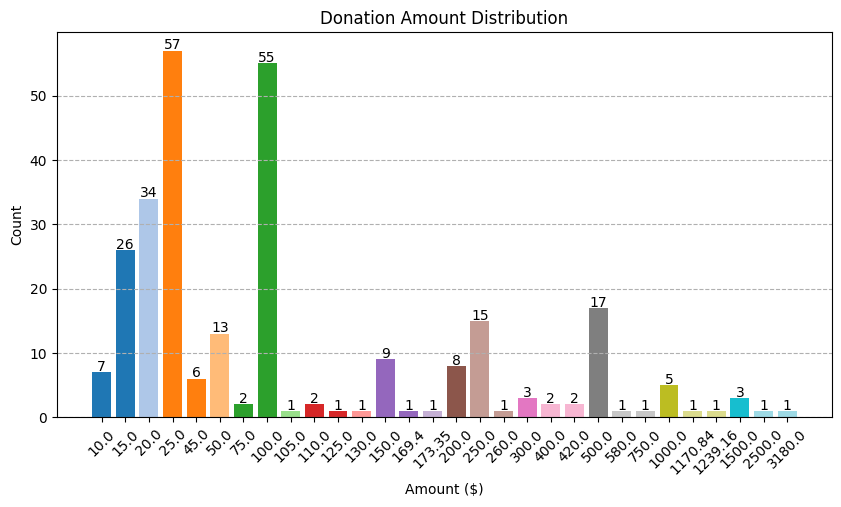

In [ ]:
amount_counts = df[COL_AMT].value_counts().sort_index()

plt.figure(figsize=(10,5))
colors = plt.cm.tab20(np.linspace(0,1,len(amount_counts)))

bars = plt.bar(amount_counts.index.astype(str), amount_counts.values, color=colors)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             int(bar.get_height()), ha='center')

plt.title("Donation Amount Distribution")
plt.xlabel("Amount ($)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.show()

5. Donor Summary (Core Table)

In [ ]:
donor_summary = (
    df.groupby("DONOR")
    .agg(
        donations_count=(COL_AMT, "count"),
        total_donated=(COL_AMT, "sum"),
        avg_donation=(COL_AMT, "mean"),
        first_donation=(COL_DATE, "min"),
        last_donation=(COL_DATE, "max")
    )
    .reset_index()
)

today = df[COL_DATE].max()
donor_summary["recency_days"] = (today - donor_summary["last_donation"]).dt.days

donor_summary.head()

,DONOR,donations_count,total_donated,avg_donation,first_donation,last_donation,recency_days
0,ANON ANON,20,4560.0,228.0,2024-01-31,2026-02-05,23
1,Adam Furfaro,1,10.0,10.0,2024-02-17,2024-02-17,742
2,Amy Hutchison,1,100.0,100.0,2024-11-14,2024-11-14,471
3,Andrea Orr,2,250.0,125.0,2024-10-27,2025-07-08,235
4,Andrew & Pronica Janikowski,4,450.0,112.5,2024-06-07,2025-12-02,88


6. Frequency Analysis (Retention Insight)

Repeat donors: 27.5%
One-time donors: 72.5%


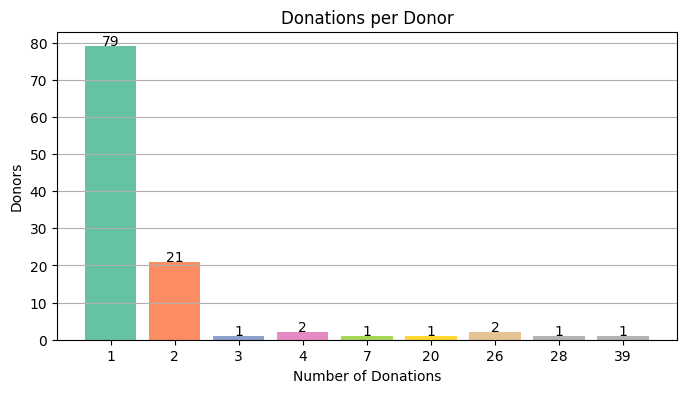

In [ ]:
repeat = (donor_summary["donations_count"] >= 2).mean() * 100
one_time = (donor_summary["donations_count"] == 1).mean() * 100

print(f"Repeat donors: {repeat:.1f}%")
print(f"One-time donors: {one_time:.1f}%")

counts = donor_summary["donations_count"].value_counts().sort_index()

plt.figure(figsize=(8,4))
colors = plt.cm.Set2(np.linspace(0,1,len(counts)))

bars = plt.bar(counts.index.astype(str), counts.values, color=colors)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             int(bar.get_height()), ha='center')

plt.title("Donations per Donor")
plt.xlabel("Number of Donations")
plt.ylabel("Donors")
plt.grid(axis='y')
plt.show()

7. Monthly Trend Analysis

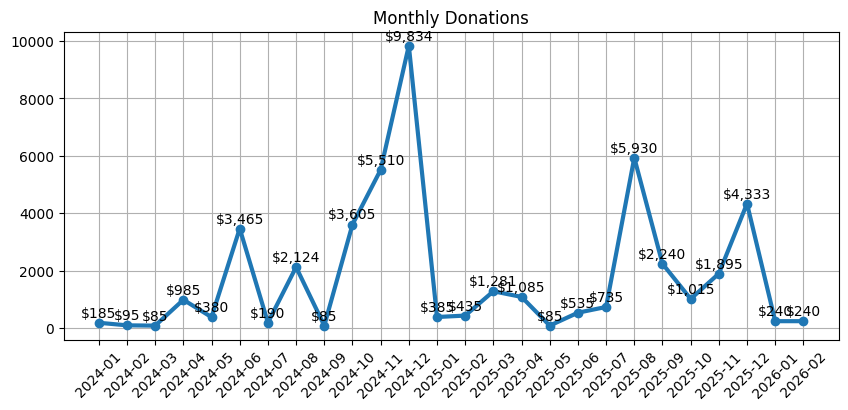

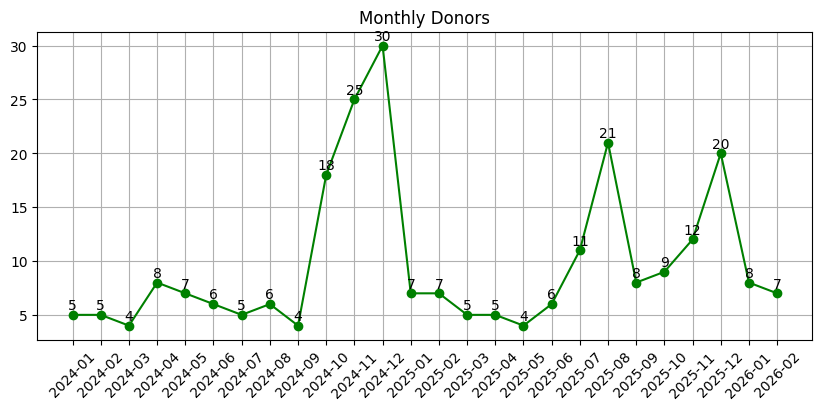

In [ ]:
monthly = df.groupby("MONTH").agg(
    total_amount=(COL_AMT, "sum"),
    unique_donors=("DONOR", "nunique")
).reset_index()

# Total donations
plt.figure(figsize=(10,4))
plt.plot(monthly["MONTH"], monthly["total_amount"], marker="o", linewidth=3)

for x,y in zip(monthly["MONTH"], monthly["total_amount"]):
    plt.text(x, y+200, f"${y:,.0f}", ha='center')

plt.title("Monthly Donations")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Donor count
plt.figure(figsize=(10,4))
plt.plot(monthly["MONTH"], monthly["unique_donors"], marker="o", color="green")

for x,y in zip(monthly["MONTH"], monthly["unique_donors"]):
    plt.text(x, y+0.5, str(y), ha='center')

plt.title("Monthly Donors")
plt.xticks(rotation=45)
plt.grid()
plt.show()

8. Year-wise Trend

In [ ]:
yearly = df.groupby("YEAR").agg(
    total_amount=(COL_AMT, "sum"),
    unique_donors=("DONOR", "nunique")
).reset_index()

print(yearly)

   YEAR  total_amount  unique_donors
0  2024      26543.56             72
1  2025      19954.19             59
2  2026        480.00              8


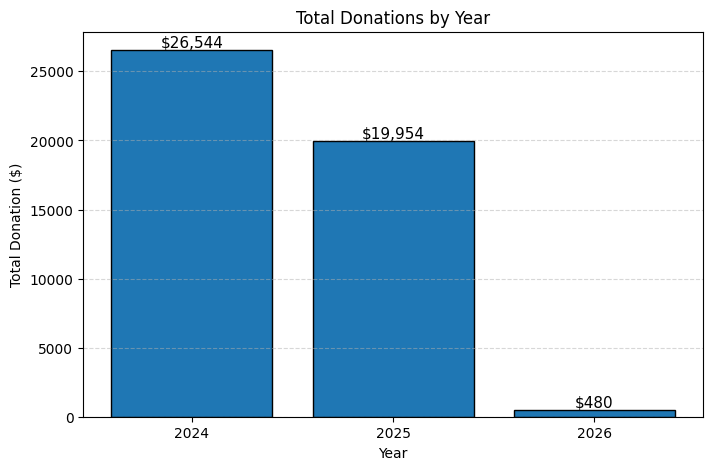

In [ ]:
plt.figure(figsize=(8,5))

bars = plt.bar(yearly["YEAR"].astype(str),
               yearly["total_amount"],
               edgecolor="black")

# Add values on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 200,
             f"${height:,.0f}",
             ha='center',
             fontsize=11)

plt.title("Total Donations by Year")
plt.xlabel("Year")
plt.ylabel("Total Donation ($)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

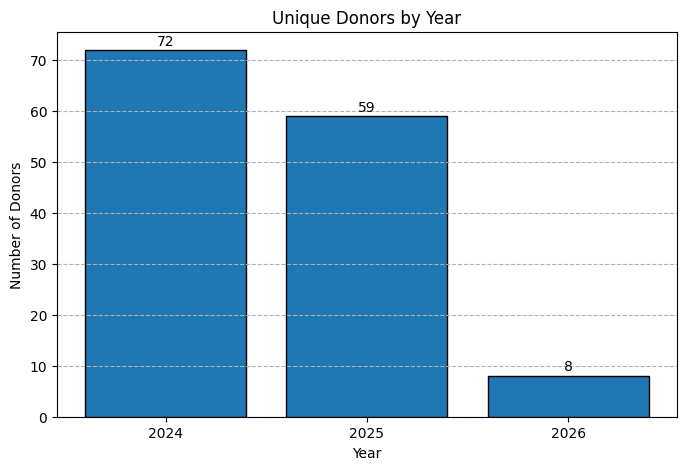

In [ ]:
plt.figure(figsize=(8,5))

bars = plt.bar(yearly["YEAR"].astype(str),
               yearly["unique_donors"],
               edgecolor="black")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 1,
             f"{int(height)}",
             ha='center')

plt.title("Unique Donors by Year")
plt.xlabel("Year")
plt.ylabel("Number of Donors")
plt.grid(axis='y', linestyle='--')

plt.show()

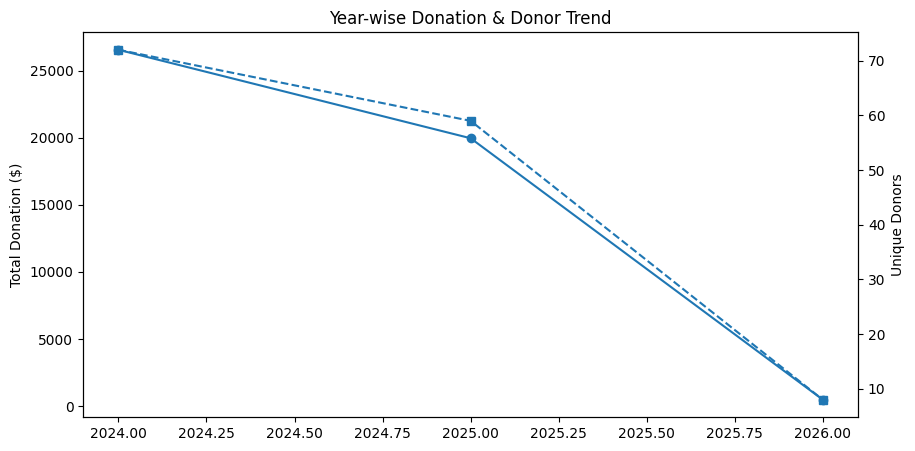

In [ ]:
fig, ax1 = plt.subplots(figsize=(10,5))

# Line for revenue
ax1.plot(yearly["YEAR"], yearly["total_amount"], marker="o")
ax1.set_ylabel("Total Donation ($)")

# Second axis for donors
ax2 = ax1.twinx()
ax2.plot(yearly["YEAR"], yearly["unique_donors"], marker="s", linestyle="--")
ax2.set_ylabel("Unique Donors")

plt.title("Year-wise Donation & Donor Trend")
plt.show()

9. Donor Retention

In [ ]:
donor_year = df.groupby(["DONOR", "YEAR"]).size().reset_index(name="count")

retention = donor_year.groupby("DONOR")["YEAR"].nunique()

retained = (retention >= 2).mean() * 100
print(f"Donors active in multiple years: {retained:.1f}%")

Donors active in multiple years: 22.0%


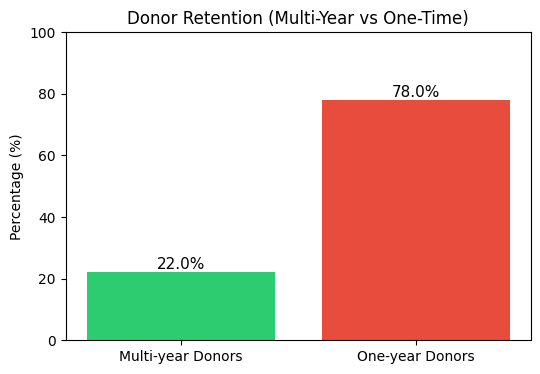

In [ ]:
retained_pct = (retention >= 2).mean() * 100
not_retained_pct = 100 - retained_pct

labels = ["Multi-year Donors", "One-year Donors"]
values = [retained_pct, not_retained_pct]

plt.figure(figsize=(6,4))

bars = plt.bar(labels, values, color=["#2ecc71", "#e74c3c"])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 1,
             f"{height:.1f}%",
             ha='center',
             fontsize=11)

plt.title("Donor Retention (Multi-Year vs One-Time)")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)

plt.show()

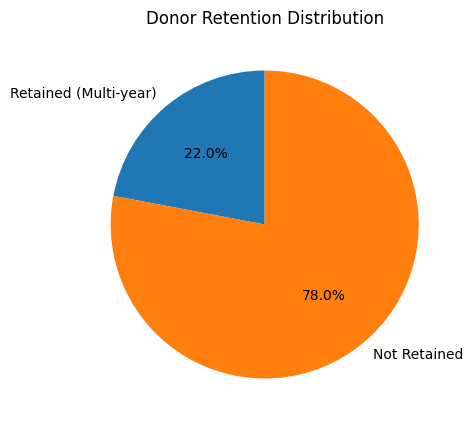

In [ ]:
labels = ["Retained (Multi-year)", "Not Retained"]
values = [retained_pct, not_retained_pct]

plt.figure(figsize=(5,5))

plt.pie(values,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Donor Retention Distribution")

plt.show()

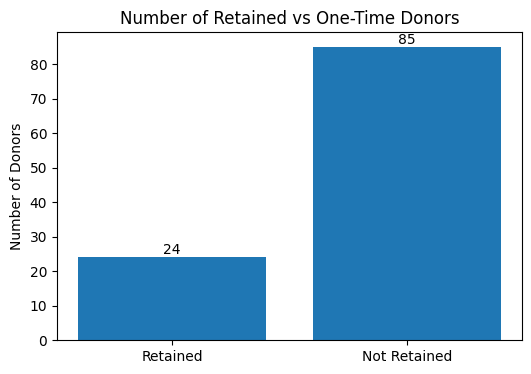

In [ ]:
retained_count = (retention >= 2).sum()
not_retained_count = (retention == 1).sum()

labels = ["Retained", "Not Retained"]
values = [retained_count, not_retained_count]

plt.figure(figsize=(6,4))

bars = plt.bar(labels, values)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+1,
             int(bar.get_height()),
             ha='center')

plt.title("Number of Retained vs One-Time Donors")
plt.ylabel("Number of Donors")

plt.show()

10. Recurring Donor Detection

In [ ]:
donor_months = df.groupby("DONOR")["MONTH"].nunique().reset_index(name="months_active")

recurring = donor_months["months_active"] >= 3
donor_months["recurring"] = recurring

donor_summary = donor_summary.merge(donor_months, on="DONOR", how="left")

11. Donor Segmentation

In [ ]:
def segment(row):
    if row["total_donated"] >= 500:
        return "High-value"
    if row["recurring"]:
        return "Recurring"
    if row["donations_count"] >= 2:
        return "Repeat"
    return "One-time"

donor_summary["segment"] = donor_summary.apply(segment, axis=1)

print(donor_summary["segment"].value_counts())

segment
One-time      66
High-value    25
Repeat        15
Recurring      3
Name: count, dtype: int64


12. Revenue by Segment

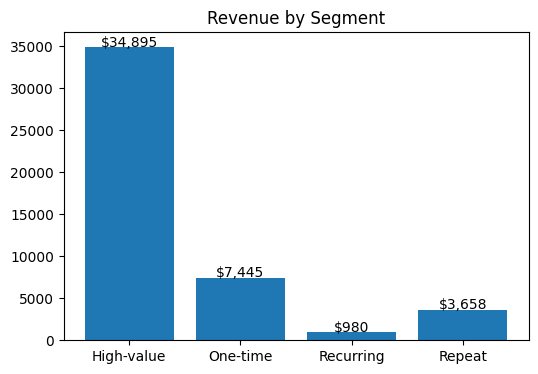

In [ ]:
rev = donor_summary.groupby("segment")["total_donated"].sum()

plt.figure(figsize=(6,4))
bars = plt.bar(rev.index, rev.values)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
             f"${bar.get_height():,.0f}", ha='center')

plt.title("Revenue by Segment")
plt.show()

13. Donation Source Analysis

In [ ]:
source = df.groupby(COL_SOURCE)[COL_AMT].agg(["count","sum"]).sort_values("sum", ascending=False)
print(source)

                                                  count       sum
DONATION SOURCE                                                  
Custom Donation Form Embedded Page                   82  28730.00
Custom Donation Form Embedded Mobile                 45   9610.00
Donations via Charity Profile on CanadaHelps.org     27   5535.00
Custom Donation Form Embedded Monthly                67   1420.00
Scheduled Giving                                     54   1090.00
Securities                                            2    342.75
Donor Favourite                                       1    250.00


14. Emotional Giving Insight

In [ ]:
df["HAS_MESSAGE"] = df[COL_MSG].notna()

msg_analysis = df.groupby("HAS_MESSAGE")[COL_AMT].mean()
print(msg_analysis)

HAS_MESSAGE
False    137.270248
True     253.278421
Name: AMOUNT, dtype: float64


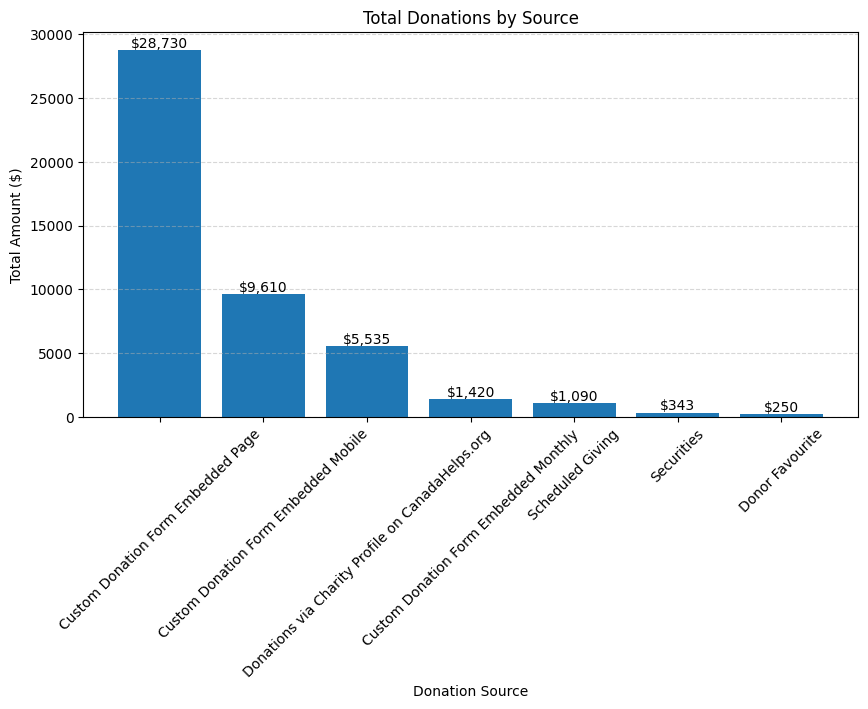

In [ ]:
plt.figure(figsize=(10,5))

bars = plt.bar(source.index, source["sum"])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,
             height + 200,
             f"${height:,.0f}",
             ha='center',
             fontsize=10)

plt.xticks(rotation=45)
plt.title("Total Donations by Source")
plt.xlabel("Donation Source")
plt.ylabel("Total Amount ($)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

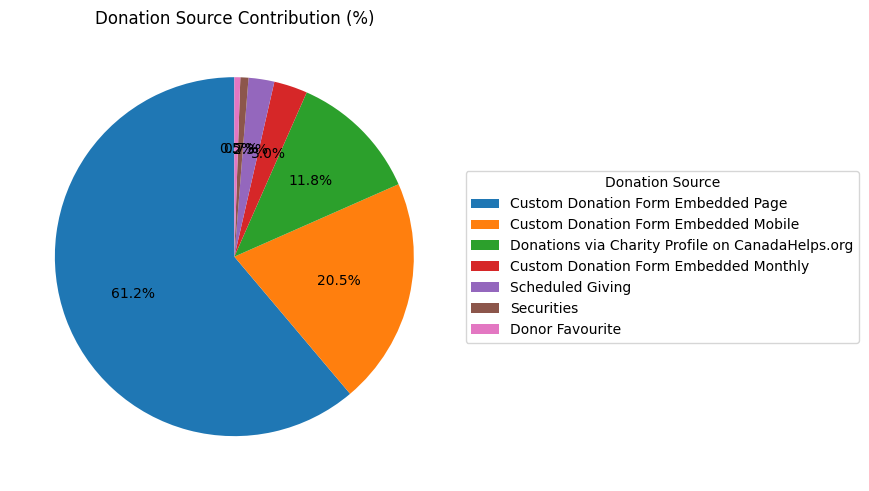

In [ ]:
plt.figure(figsize=(8,6))

# Pie without labels
wedges, texts, autotexts = plt.pie(
    source_pct,
    autopct='%1.1f%%',
    startangle=90
)

# Add legend separately
plt.legend(
    wedges,
    source.index,
    title="Donation Source",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Donation Source Contribution (%)")

plt.tight_layout()
plt.show()

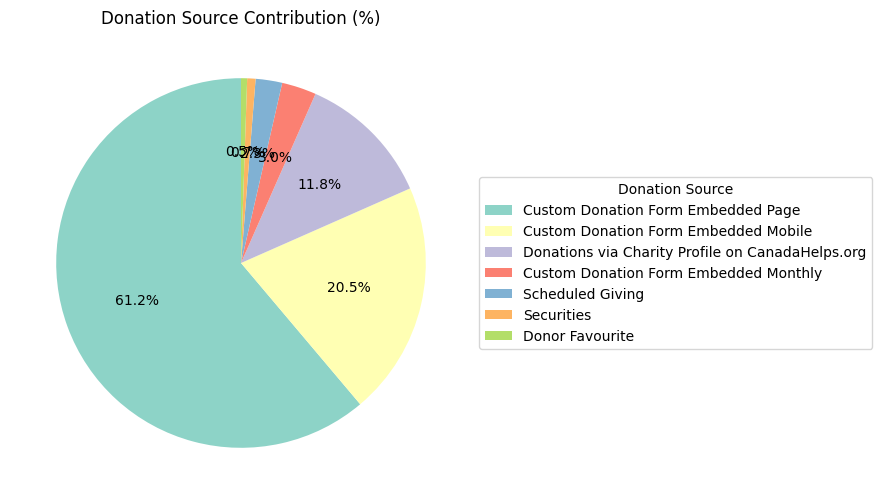

In [ ]:
plt.figure(figsize=(8,6))

colors = plt.cm.Set3(range(len(source_pct)))

wedges, texts, autotexts = plt.pie(
    source_pct,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.legend(
    wedges,
    source.index,
    title="Donation Source",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Donation Source Contribution (%)")

plt.show()

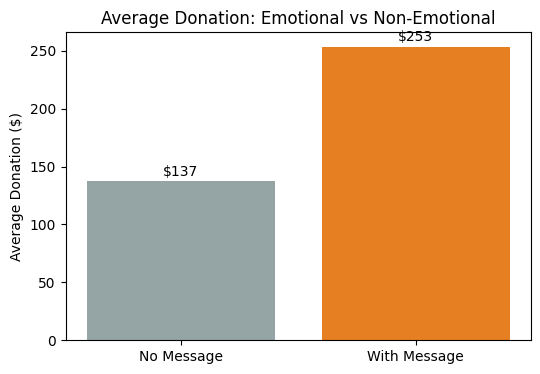

In [ ]:
labels = ["No Message", "With Message"]
values = msg_analysis.values

plt.figure(figsize=(6,4))

bars = plt.bar(labels, values, color=["#95a5a6", "#e67e22"])

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+5,
             f"${bar.get_height():.0f}",
             ha='center')

plt.title("Average Donation: Emotional vs Non-Emotional")
plt.ylabel("Average Donation ($)")

plt.show()

15. Top Donors

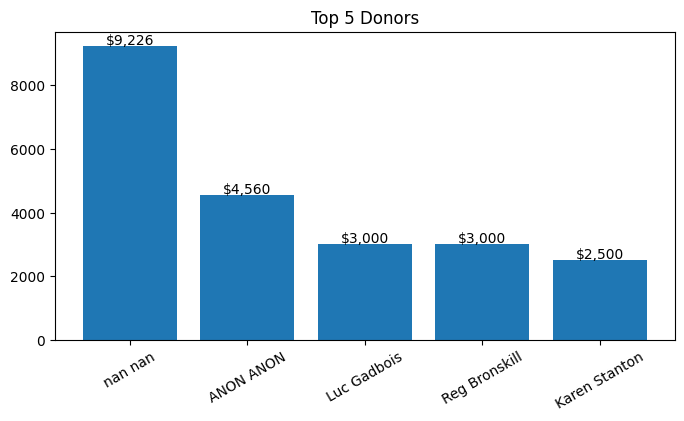

In [ ]:
top5 = donor_summary.sort_values("total_donated", ascending=False).head(5)

plt.figure(figsize=(8,4))
bars = plt.bar(top5["DONOR"], top5["total_donated"])

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
             f"${bar.get_height():,.0f}", ha='center')

plt.xticks(rotation=30)
plt.title("Top 5 Donors")
plt.show()

PAYMENT METHOD ANALYSIS

In [ ]:
# Identify payment method column
COL_PAY = None
for c in df.columns:
    if "PAYMENT" in c:
        COL_PAY = c
        break

print("Using Payment Column:", COL_PAY)

# Summary
payment_summary = df.groupby(COL_PAY)[COL_AMT].agg(
    total_amount="sum",
    count="count",
    avg_donation="mean"
).sort_values("total_amount", ascending=False)

print(payment_summary)

Using Payment Column: PAYMENT METHOD
                total_amount  count  avg_donation
PAYMENT METHOD                                   
Credit Card         39835.00    248    160.625000
Paypal               6070.00     19    319.473684
GooglePay             720.00      8     90.000000
Securities            342.75      2    171.375000
Gift Card              10.00      1     10.000000


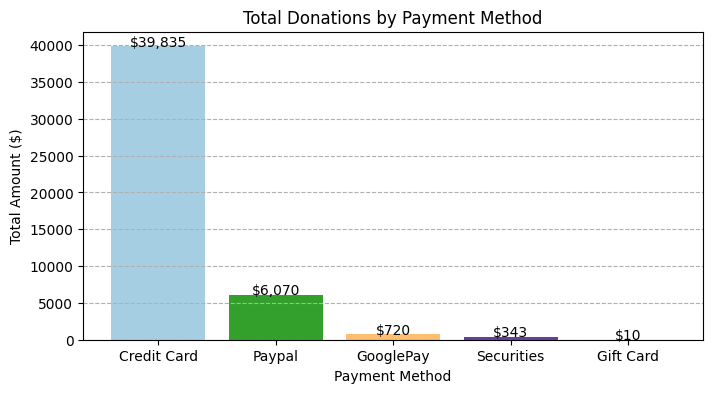

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,4))

colors = plt.cm.Paired(np.linspace(0,1,len(payment_summary)))

bars = plt.bar(payment_summary.index, payment_summary["total_amount"], color=colors)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, height+50,
             f"${height:,.0f}", ha='center')

plt.title("Total Donations by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Amount ($)")
plt.grid(axis='y', linestyle='--')
plt.show()

REPEAT DONOR IDENTIFICATION

In [ ]:
donor_summary["is_repeat"] = donor_summary["donations_count"] >= 2

In [ ]:
df = df.merge(donor_summary[["DONOR", "is_repeat"]], on="DONOR", how="left")

In [ ]:
repeat_analysis = df.groupby("is_repeat")[COL_AMT].agg(
    total_amount="sum",
    count="count",
    avg_donation="mean"
)

print(repeat_analysis)

           total_amount  count  avg_donation
is_repeat                                   
False          17184.16     79    217.521013
True           29793.59    199    149.716533


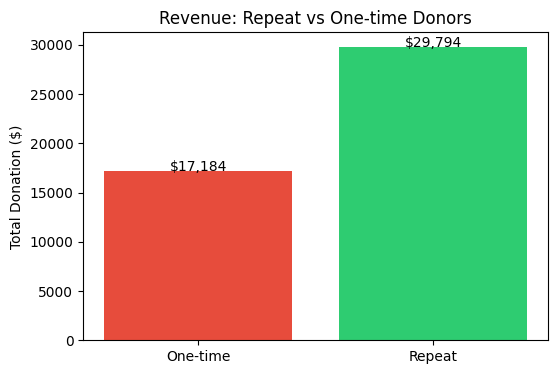

In [ ]:
labels = ["One-time", "Repeat"]
values = df.groupby("is_repeat")[COL_AMT].sum()

plt.figure(figsize=(6,4))

bars = plt.bar(labels, values, color=["#e74c3c","#2ecc71"])

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
             f"${bar.get_height():,.0f}", ha='center')

plt.title("Revenue: Repeat vs One-time Donors")
plt.ylabel("Total Donation ($)")
plt.show()

In [ ]:
repeat_donors = donor_summary[donor_summary["is_repeat"] == True]

repeat_donors.sort_values("total_donated", ascending=False).head(10)

,DONOR,donations_count,total_donated,avg_donation,first_donation,last_donation,recency_days,months_active,recurring,segment,is_repeat
106,nan nan,39,9225.84,236.560000,2024-01-17,2026-02-17,11,26,True,High-value,True
0,ANON ANON,20,4560.00,228.000000,2024-01-31,2026-02-05,23,11,True,High-value,True
66,Luc Gadbois,3,3000.00,1000.000000,2024-10-11,2025-08-26,186,3,True,High-value,True
82,Reg Bronskill,2,3000.00,1500.000000,2024-11-22,2025-09-08,173,2,False,High-value,True
83,Richard Melvin,2,1000.00,500.000000,2024-11-21,2025-08-27,185,2,False,High-value,True
11,Catharine Wilson-Pote,28,850.00,30.357143,2024-01-13,2026-02-13,15,26,True,High-value,True
41,Jeffrey Kraegel,2,840.00,420.000000,2024-12-29,2025-12-31,59,2,False,High-value,True
31,Faye Moxam,2,600.00,300.000000,2024-12-25,2025-12-02,88,2,False,High-value,True
55,Kim Haigh,4,550.00,137.500000,2024-12-21,2026-02-07,21,4,True,High-value,True
108,wendy mesley,26,520.00,20.000000,2024-01-28,2026-02-28,0,26,True,High-value,True


In [ ]:
top10 = donor_summary.sort_values("total_donated", ascending=False).head(10)[
    ["DONOR", "donations_count", "total_donated"]
]

top10

,DONOR,donations_count,total_donated
106,nan nan,39,9225.84
0,ANON ANON,20,4560.00
66,Luc Gadbois,3,3000.00
82,Reg Bronskill,2,3000.00
49,Karen Stanton,1,2500.00
95,Tina Nguyen,1,1239.16
20,Don Stanton,1,1000.00
83,Richard Melvin,2,1000.00
11,Catharine Wilson-Pote,28,850.00
41,Jeffrey Kraegel,2,840.00


In [ ]:
print("Top 10 Donors:\n")
for i, row in top10.iterrows():
    print(f"{row['DONOR']} → {row['donations_count']} donations | ${row['total_donated']:,.2f}")

Top 10 Donors:

nan nan → 39 donations | $9,225.84
ANON ANON → 20 donations | $4,560.00
Luc Gadbois → 3 donations | $3,000.00
Reg Bronskill → 2 donations | $3,000.00
Karen Stanton → 1 donations | $2,500.00
Tina Nguyen → 1 donations | $1,239.16
Don Stanton → 1 donations | $1,000.00
Richard Melvin → 2 donations | $1,000.00
Catharine Wilson-Pote → 28 donations | $850.00
Jeffrey Kraegel → 2 donations | $840.00


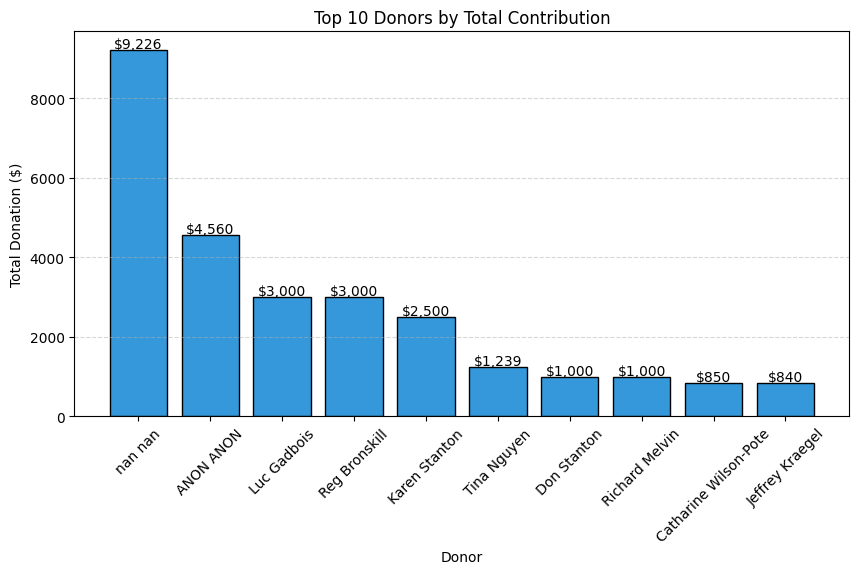

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

bars = plt.bar(top10["DONOR"], top10["total_donated"],
               color="#3498db", edgecolor="black")

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 50,
             f"${height:,.0f}",
             ha='center',
             fontsize=10)

plt.title("Top 10 Donors by Total Contribution")
plt.xlabel("Donor")
plt.ylabel("Total Donation ($)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

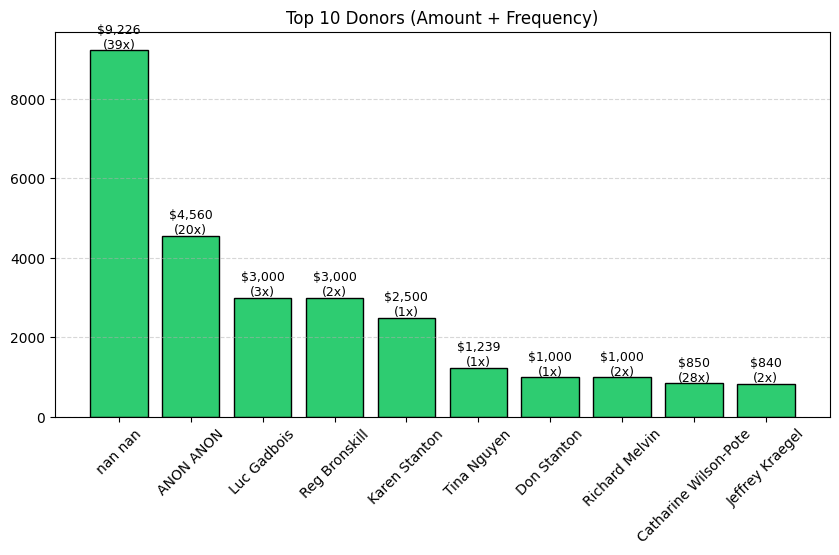

In [ ]:
plt.figure(figsize=(10,5))

bars = plt.bar(top10["DONOR"], top10["total_donated"],
               color="#2ecc71", edgecolor="black")

for bar, count in zip(bars, top10["donations_count"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 50,
             f"${height:,.0f}\n({count}x)",
             ha='center',
             fontsize=9)

plt.title("Top 10 Donors (Amount + Frequency)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

16. Final Metrics

In [ ]:
print("Total donors:", donor_summary.shape[0])
print("Total revenue:", df[COL_AMT].sum())
print("Avg donation:", df[COL_AMT].mean())

Total donors: 109
Total revenue: 46977.75
Avg donation: 168.98471223021582
